In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed(42)

Using device: cuda


In [21]:
from torchvision import datasets, transforms

In [2]:
class TwoLayerMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, activation='relu'):
        super(TwoLayerMLP, self).__init__()
        # First layer: W1^T.x + b1
        self.fc1 = nn.Linear(input_size, hidden_size)
        # Second layer: W2^T.x + b2
        self.fc2 = nn.Linear(hidden_size, output_size)

        # Activation function selection
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        else:
            raise ValueError("Activation must be 'relu' or 'sigmoid'")

    def forward(self, x):
        # First layer: W1^T.x + b1
        out = self.fc1(x)
        # Activation function
        out = self.activation(out)
        # Second layer: W2^T.x + b2
        out = self.fc2(out)
        return out

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, problem_type='classification'):
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass
            outputs = model(inputs)

            # Compute loss
            if problem_type == 'classification':
                loss = criterion(outputs, targets)
            else:  # regression
                loss = criterion(outputs, targets.view(-1, 1))

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Calculate average training loss
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)

                if problem_type == 'classification':
                    loss = criterion(outputs, targets)
                    _, predicted = torch.max(outputs.data, 1)
                    total += targets.size(0)
                    correct += (predicted == targets).sum().item()
                else:  # regression
                    loss = criterion(outputs, targets.view(-1, 1))

                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if problem_type == 'classification':
            val_accuracy = 100 * correct / total
            val_accuracies.append(val_accuracy)
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train Loss: {avg_train_loss:.4f}, '
                  f'Val Loss: {avg_val_loss:.4f}, '
                  f'Val Acc: {val_accuracy:.2f}%')
        else:
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train Loss: {avg_train_loss:.4f}, '
                  f'Val Loss: {avg_val_loss:.4f}')

    return train_losses, val_losses, val_accuracies

In [4]:
def classification_example():
    print("=== Classification Example ===")

    # Generate moons dataset
    X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

    # Split and scale data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.LongTensor(y_test).to(device)

    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Train with ReLU activation
    print("\n--- Training with ReLU activation ---")
    model_relu = TwoLayerMLP(input_size=2, hidden_size=10, output_size=2, activation='relu').to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_relu.parameters(), lr=0.01)

    start_time = time.time()
    train_losses_relu, val_losses_relu, val_accuracies_relu = train_model(
        model_relu, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, problem_type='classification'
    )
    relu_time = time.time() - start_time

    # Train with Sigmoid activation
    print("\n--- Training with Sigmoid activation ---")
    model_sigmoid = TwoLayerMLP(input_size=2, hidden_size=10, output_size=2, activation='sigmoid').to(device)
    optimizer = optim.Adam(model_sigmoid.parameters(), lr=0.01)

    start_time = time.time()
    train_losses_sigmoid, val_losses_sigmoid, val_accuracies_sigmoid = train_model(
        model_sigmoid, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, problem_type='classification'
    )
    sigmoid_time = time.time() - start_time

    # Compare performance
    print(f"\nReLU training time: {relu_time:.2f}s")
    print(f"Sigmoid training time: {sigmoid_time:.2f}s")

    # Plot results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses_relu, label='ReLU Train')
    plt.plot(val_losses_relu, label='ReLU Val')
    plt.plot(train_losses_sigmoid, label='Sigmoid Train')
    plt.plot(val_losses_sigmoid, label='Sigmoid Val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies_relu, label='ReLU')
    plt.plot(val_accuracies_sigmoid, label='Sigmoid')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Validation Accuracy')

    plt.tight_layout()
    plt.show()

    # Test final performance
    model_relu.eval()
    model_sigmoid.eval()

    with torch.no_grad():
        # ReLU model
        outputs_relu = model_relu(X_test_t)
        _, predicted_relu = torch.max(outputs_relu.data, 1)
        accuracy_relu = (predicted_relu == y_test_t).sum().item() / y_test_t.size(0) * 100

        # Sigmoid model
        outputs_sigmoid = model_sigmoid(X_test_t)
        _, predicted_sigmoid = torch.max(outputs_sigmoid.data, 1)
        accuracy_sigmoid = (predicted_sigmoid == y_test_t).sum().item() / y_test_t.size(0) * 100

    print(f"\nFinal Test Accuracy:")
    print(f"ReLU: {accuracy_relu:.2f}%")
    print(f"Sigmoid: {accuracy_sigmoid:.2f}%")

    return model_relu, model_sigmoid, X_test_t, y_test_t

In [5]:
def regression_example():
    print("\n=== Regression Example ===")

    # Generate regression dataset
    X, y = make_regression(n_samples=1000, n_features=5, noise=0.1, random_state=42)

    # Split and scale data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    X_scaler = StandardScaler()
    X_train = X_scaler.fit_transform(X_train)
    X_val = X_scaler.transform(X_val)
    X_test = X_scaler.transform(X_test)

    y_scaler = StandardScaler()
    y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
    y_val = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
    y_test = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

    # Convert to tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.FloatTensor(y_val).to(device)
    X_test_t = torch.FloatTensor(X_test).to(device)
    y_test_t = torch.FloatTensor(y_test).to(device)

    # Create datasets and dataloaders
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Train with ReLU activation
    print("\n--- Training with ReLU activation ---")
    model_relu = TwoLayerMLP(input_size=5, hidden_size=10, output_size=1, activation='relu').to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_relu.parameters(), lr=0.01)

    train_losses_relu, val_losses_relu, _ = train_model(
        model_relu, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, problem_type='regression'
    )

    # Train with Sigmoid activation
    print("\n--- Training with Sigmoid activation ---")
    model_sigmoid = TwoLayerMLP(input_size=5, hidden_size=10, output_size=1, activation='sigmoid').to(device)
    optimizer = optim.Adam(model_sigmoid.parameters(), lr=0.01)

    train_losses_sigmoid, val_losses_sigmoid, _ = train_model(
        model_sigmoid, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, problem_type='regression'
    )

    # Plot results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses_relu, label='ReLU Train')
    plt.plot(val_losses_relu, label='ReLU Val')
    plt.plot(train_losses_sigmoid, label='Sigmoid Train')
    plt.plot(val_losses_sigmoid, label='Sigmoid Val')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.title('Training and Validation Loss')

    # Test final performance
    model_relu.eval()
    model_sigmoid.eval()

    with torch.no_grad():
        # ReLU model
        outputs_relu = model_relu(X_test_t)
        mse_relu = criterion(outputs_relu, y_test_t.view(-1, 1))

        # Sigmoid model
        outputs_sigmoid = model_sigmoid(X_test_t)
        mse_sigmoid = criterion(outputs_sigmoid, y_test_t.view(-1, 1))

    print(f"\nFinal Test MSE:")
    print(f"ReLU: {mse_relu.item():.4f}")
    print(f"Sigmoid: {mse_sigmoid.item():.4f}")

    # Plot predictions vs actual
    plt.subplot(1, 2, 2)
    plt.scatter(y_test_t.cpu().numpy(), outputs_relu.cpu().numpy(), alpha=0.5, label='ReLU')
    plt.scatter(y_test_t.cpu().numpy(), outputs_sigmoid.cpu().numpy(), alpha=0.5, label='Sigmoid')
    plt.plot([y_test_t.min().item(), y_test_t.max().item()],
             [y_test_t.min().item(), y_test_t.max().item()], 'r--')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.legend()
    plt.title('Predictions vs Actual')

    plt.tight_layout()
    plt.show()

    return model_relu, model_sigmoid, X_test_t, y_test_t

=== Classification Example ===

--- Training with ReLU activation ---
Epoch [1/100], Train Loss: 0.6031, Val Loss: 0.4223, Val Acc: 81.25%
Epoch [2/100], Train Loss: 0.3681, Val Loss: 0.2882, Val Acc: 83.75%
Epoch [3/100], Train Loss: 0.3069, Val Loss: 0.2652, Val Acc: 86.88%
Epoch [4/100], Train Loss: 0.2897, Val Loss: 0.2517, Val Acc: 86.88%
Epoch [5/100], Train Loss: 0.2771, Val Loss: 0.2426, Val Acc: 87.50%
Epoch [6/100], Train Loss: 0.2647, Val Loss: 0.2320, Val Acc: 87.50%
Epoch [7/100], Train Loss: 0.2526, Val Loss: 0.2199, Val Acc: 89.38%
Epoch [8/100], Train Loss: 0.2398, Val Loss: 0.2045, Val Acc: 89.38%
Epoch [9/100], Train Loss: 0.2212, Val Loss: 0.1883, Val Acc: 92.50%
Epoch [10/100], Train Loss: 0.2059, Val Loss: 0.1711, Val Acc: 93.12%
Epoch [11/100], Train Loss: 0.1902, Val Loss: 0.1561, Val Acc: 95.00%
Epoch [12/100], Train Loss: 0.1747, Val Loss: 0.1425, Val Acc: 95.00%
Epoch [13/100], Train Loss: 0.1620, Val Loss: 0.1288, Val Acc: 95.62%
Epoch [14/100], Train Loss: 0

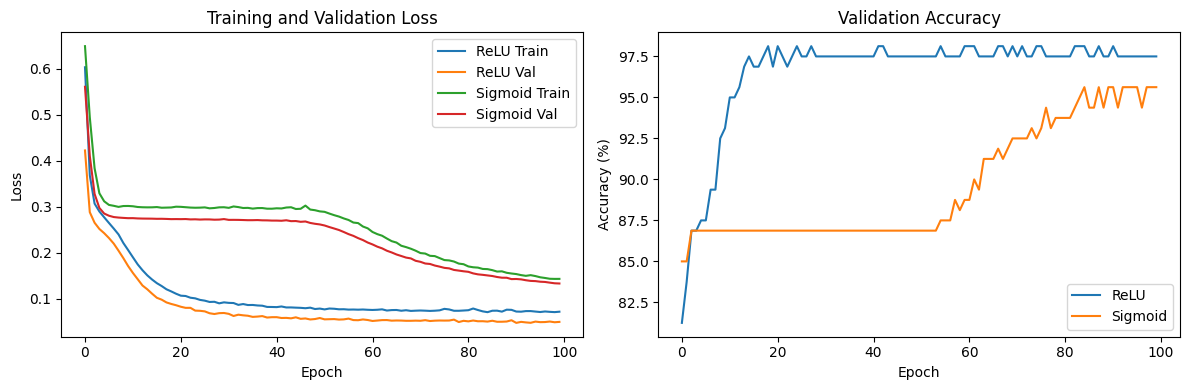


Final Test Accuracy:
ReLU: 98.00%
Sigmoid: 95.50%

=== Regression Example ===

--- Training with ReLU activation ---
Epoch [1/100], Train Loss: 0.6811, Val Loss: 0.2589
Epoch [2/100], Train Loss: 0.0935, Val Loss: 0.0286
Epoch [3/100], Train Loss: 0.0251, Val Loss: 0.0167
Epoch [4/100], Train Loss: 0.0110, Val Loss: 0.0103
Epoch [5/100], Train Loss: 0.0082, Val Loss: 0.0077
Epoch [6/100], Train Loss: 0.0065, Val Loss: 0.0067
Epoch [7/100], Train Loss: 0.0054, Val Loss: 0.0056
Epoch [8/100], Train Loss: 0.0046, Val Loss: 0.0045
Epoch [9/100], Train Loss: 0.0039, Val Loss: 0.0039
Epoch [10/100], Train Loss: 0.0031, Val Loss: 0.0039
Epoch [11/100], Train Loss: 0.0026, Val Loss: 0.0029
Epoch [12/100], Train Loss: 0.0021, Val Loss: 0.0026
Epoch [13/100], Train Loss: 0.0017, Val Loss: 0.0022
Epoch [14/100], Train Loss: 0.0015, Val Loss: 0.0018
Epoch [15/100], Train Loss: 0.0013, Val Loss: 0.0018
Epoch [16/100], Train Loss: 0.0011, Val Loss: 0.0015
Epoch [17/100], Train Loss: 0.0010, Val Los

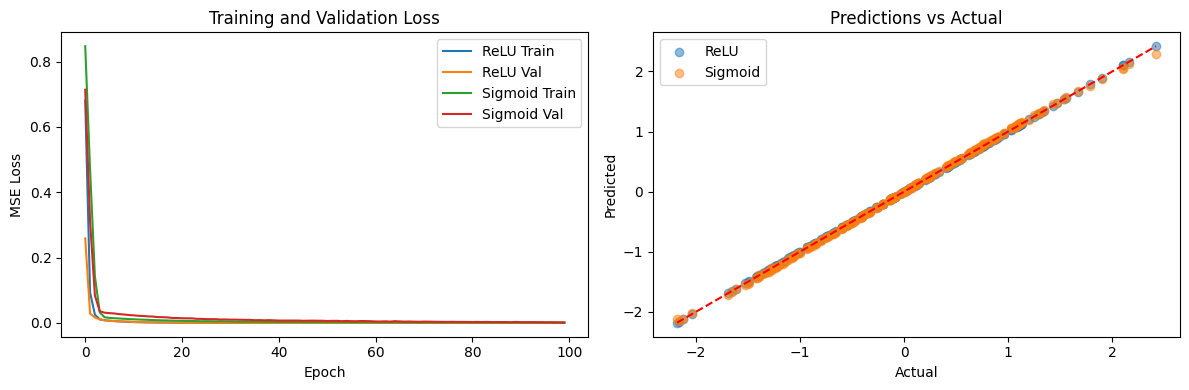


=== Key Takeaways ===
1. ReLU generally trains faster and achieves better performance than sigmoid
2. Sigmoid suffers from the vanishing gradient problem, especially in deep networks
3. ReLU helps mitigate vanishing gradients by having a constant gradient of 1 for positive inputs
4. For classification, use CrossEntropyLoss with raw logits (no softmax in the output)
5. For regression, use MSELoss and consider scaling your target variable


In [6]:

# Run classification example
cls_model_relu, cls_model_sigmoid, X_test_cls, y_test_cls = classification_example()

# Run regression example
reg_model_relu, reg_model_sigmoid, X_test_reg, y_test_reg = regression_example()

print("\n=== Key Takeaways ===")
print("1. ReLU generally trains faster and achieves better performance than sigmoid")
print("2. Sigmoid suffers from the vanishing gradient problem, especially in deep networks")
print("3. ReLU helps mitigate vanishing gradients by having a constant gradient of 1 for positive inputs")
print("4. For classification, use CrossEntropyLoss with raw logits (no softmax in the output)")
print("5. For regression, use MSELoss and consider scaling your target variable")

#Objectives

###Implement a two-layer MLP for both classification and regression tasks.

###Understand the effect of different activation functions (ReLU vs Sigmoid).

###Train and evaluate models on GPU using PyTorch.

###Gain hands-on experience with loss functions, optimizers, and data loaders.

#Task 1: Implement a Two-Layer MLP

Implement the MLP using the $W^Tx+b$ formulation in PyTorch.

Support both ReLU and Sigmoid activation functions.

Ensure your model runs on GPU (if available).

👉 Use the provided boilerplate TwoLayerMLP class as a starting point.

#Task 2: Classification on MNIST (Digits 0 and 1)

Load MNIST dataset but only keep digits 0 and 1.

Train your MLP for binary classification:

Input dimension: $28\times 28$

Hidden dimension: $128$

Output dimension: $2$

Use CrossEntropyLoss and SGD optimizer.

##Train for 5 epochs and report training & testing accuracy.

##Questions (5 marks):

###Q1: Report the final training accuracy and testing accuracy.

###Q2: How many parameters does your model have? Show calculation.

###Q3: Try changing the hidden layer size to 64 and 256. How does accuracy change?

### ---- Task 2 ----

In [ ]:
def task2(hidden_size=128, num_epoch=5):
    print(f"\n Task2: MNIST Classification with hidden size {hidden_size}")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1))
    ])

    train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    #filtering in only 0 and 1
    train_idx = [i for i, t in enumerate(train_data.targets) if t in [0, 1]]
    test_idx = [i for i, t in enumerate(test_data.targets) if t in [0, 1]]
    train_data = Subset(train_data, train_idx)
    test_data = Subset(test_data, test_idx)

    train_loader = DataLoader(train_data, batch_size=64, shuffle=True) #to improve minibatch performance
    test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

    model = TwoLayerMLP(input_size=784, hidden_size=hidden_size, output_size=2, activation="relu").to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    for epoch in range(num_epoch):
        model.train()
        correct, total = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
        acc = 100 * correct / total
        print(f"Epoch {epoch+1}: Train Acc = {acc:.2f}%")

    model.eval()
    with torch.no_grad():
        correct, total = 0, 0
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = torch.max(out, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
        test_acc = 100 * correct / total

    print(f"Final Training Accuracy: {acc:.2f}%")
    print(f"Final Testing Accuracy: {test_acc:.2f}%")

    return model, acc, test_acc

In [8]:
task2()


 Task2: MNIST Classification with hidden size 128
Epoch 1: Train Acc = 98.68%
Epoch 2: Train Acc = 99.72%
Epoch 3: Train Acc = 99.75%
Epoch 4: Train Acc = 99.74%
Epoch 5: Train Acc = 99.76%
Final Training Accuracy: 99.76%
Final Testing Accuracy: 99.91%


(TwoLayerMLP(
   (fc1): Linear(in_features=784, out_features=128, bias=True)
   (fc2): Linear(in_features=128, out_features=2, bias=True)
   (activation): ReLU()
 ),
 99.76312672720094,
 99.90543735224587)

#### ---- Task 2 Q1 ----

Final Training Accuracy: 99.77%
Final Testing Accuracy: 99.91%

#### ---- Task 2 Q2 ----

(input_dimension * hidden_shape + hidden_shape) + (hidden_shape*output_shape + output_shape)

=> (784*128 + 128) + (128*2+2)

=> 100,738 parameters

In [9]:
task2(hidden_size=64)


 Task2: MNIST Classification with hidden size 64
Epoch 1: Train Acc = 97.47%
Epoch 2: Train Acc = 99.69%
Epoch 3: Train Acc = 99.75%
Epoch 4: Train Acc = 99.76%
Epoch 5: Train Acc = 99.76%
Final Training Accuracy: 99.76%
Final Testing Accuracy: 99.91%


(TwoLayerMLP(
   (fc1): Linear(in_features=784, out_features=64, bias=True)
   (fc2): Linear(in_features=64, out_features=2, bias=True)
   (activation): ReLU()
 ),
 99.76312672720094,
 99.90543735224587)

In [10]:
task2(hidden_size=256)


 Task2: MNIST Classification with hidden size 256
Epoch 1: Train Acc = 98.14%
Epoch 2: Train Acc = 99.70%
Epoch 3: Train Acc = 99.76%
Epoch 4: Train Acc = 99.76%
Epoch 5: Train Acc = 99.76%
Final Training Accuracy: 99.76%
Final Testing Accuracy: 99.91%


(TwoLayerMLP(
   (fc1): Linear(in_features=784, out_features=256, bias=True)
   (fc2): Linear(in_features=256, out_features=2, bias=True)
   (activation): ReLU()
 ),
 99.76312672720094,
 99.90543735224587)

In [11]:
task2(hidden_size=64, num_epoch=10)

task2(num_epoch=10)

task2(hidden_size=256, num_epoch=10)


 Task2: MNIST Classification with hidden size 64
Epoch 1: Train Acc = 99.01%
Epoch 2: Train Acc = 99.69%
Epoch 3: Train Acc = 99.73%
Epoch 4: Train Acc = 99.74%
Epoch 5: Train Acc = 99.75%
Epoch 6: Train Acc = 99.77%
Epoch 7: Train Acc = 99.78%
Epoch 8: Train Acc = 99.79%
Epoch 9: Train Acc = 99.79%
Epoch 10: Train Acc = 99.80%
Final Training Accuracy: 99.80%
Final Testing Accuracy: 99.95%

 Task2: MNIST Classification with hidden size 128
Epoch 1: Train Acc = 98.29%
Epoch 2: Train Acc = 99.73%
Epoch 3: Train Acc = 99.76%
Epoch 4: Train Acc = 99.77%
Epoch 5: Train Acc = 99.77%
Epoch 6: Train Acc = 99.78%
Epoch 7: Train Acc = 99.79%
Epoch 8: Train Acc = 99.79%
Epoch 9: Train Acc = 99.79%
Epoch 10: Train Acc = 99.79%
Final Training Accuracy: 99.79%
Final Testing Accuracy: 99.95%

 Task2: MNIST Classification with hidden size 256
Epoch 1: Train Acc = 97.99%
Epoch 2: Train Acc = 99.69%
Epoch 3: Train Acc = 99.73%
Epoch 4: Train Acc = 99.76%
Epoch 5: Train Acc = 99.76%
Epoch 6: Train Acc =

(TwoLayerMLP(
   (fc1): Linear(in_features=784, out_features=256, bias=True)
   (fc2): Linear(in_features=256, out_features=2, bias=True)
   (activation): ReLU()
 ),
 99.8262929332807,
 99.95271867612293)

#### ---- Task 2 Q3 ----

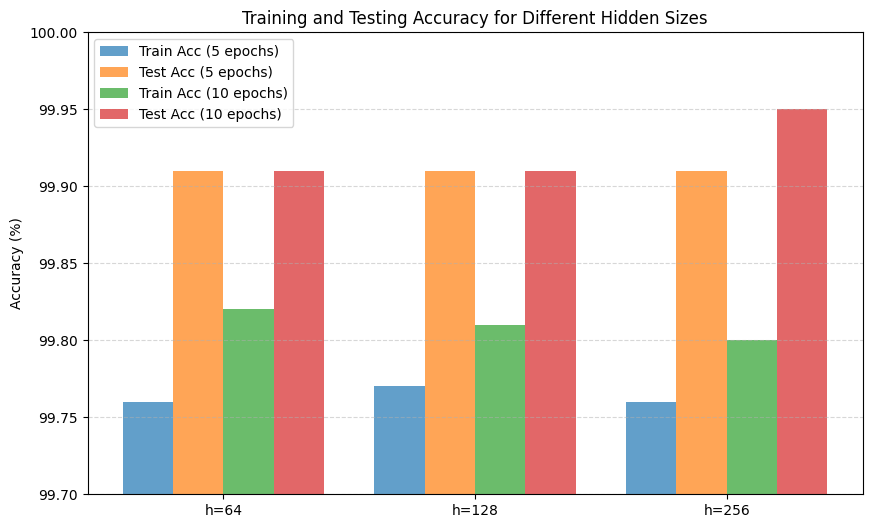

In [ ]:
# Data
hidden_sizes = [64, 128, 256]

train_acc_5 = [99.76, 99.77, 99.76]
test_acc_5 = [99.91, 99.91, 99.91]

train_acc_10 = [99.82, 99.81, 99.80]
test_acc_10 = [99.91, 99.91, 99.95]

x = np.arange(len(hidden_sizes))  # x positions
width = 0.2  # bar width

plt.figure(figsize=(10,6))

# 5 epoch bars
plt.bar(x - width*1.5, train_acc_5, width, label="Train Acc (5 epochs)", alpha=0.7)
plt.bar(x - width*0.5, test_acc_5, width, label="Test Acc (5 epochs)", alpha=0.7)

# 10 epoch bars
plt.bar(x + width*0.5, train_acc_10, width, label="Train Acc (10 epochs)", alpha=0.7)
plt.bar(x + width*1.5, test_acc_10, width, label="Test Acc (10 epochs)", alpha=0.7)

# Labels and formatting
plt.xticks(x, [f"h={h}" for h in hidden_sizes])
plt.ylabel("Accuracy (%)")
plt.title("Training and Testing Accuracy for Different Hidden Sizes")
plt.ylim(99.7, 100.0)
plt.legend()
plt.grid(axis='y', linestyle="--", alpha=0.5)

plt.show()

In [13]:
task2(hidden_size=32)


 Task2: MNIST Classification with hidden size 32
Epoch 1: Train Acc = 98.26%
Epoch 2: Train Acc = 99.71%
Epoch 3: Train Acc = 99.74%
Epoch 4: Train Acc = 99.76%
Epoch 5: Train Acc = 99.78%
Final Training Accuracy: 99.78%
Final Testing Accuracy: 99.91%


(TwoLayerMLP(
   (fc1): Linear(in_features=784, out_features=32, bias=True)
   (fc2): Linear(in_features=32, out_features=2, bias=True)
   (activation): ReLU()
 ),
 99.77891827872088,
 99.90543735224587)

In [14]:
task2(hidden_size=16)


 Task2: MNIST Classification with hidden size 16
Epoch 1: Train Acc = 96.41%
Epoch 2: Train Acc = 99.66%
Epoch 3: Train Acc = 99.72%
Epoch 4: Train Acc = 99.72%
Epoch 5: Train Acc = 99.77%
Final Training Accuracy: 99.77%
Final Testing Accuracy: 99.95%


(TwoLayerMLP(
   (fc1): Linear(in_features=784, out_features=16, bias=True)
   (fc2): Linear(in_features=16, out_features=2, bias=True)
   (activation): ReLU()
 ),
 99.77102250296092,
 99.95271867612293)

In [15]:
task2(hidden_size=8, num_epoch=3)


 Task2: MNIST Classification with hidden size 8
Epoch 1: Train Acc = 94.39%
Epoch 2: Train Acc = 99.65%
Epoch 3: Train Acc = 99.73%
Final Training Accuracy: 99.73%
Final Testing Accuracy: 99.91%


(TwoLayerMLP(
   (fc1): Linear(in_features=784, out_features=8, bias=True)
   (fc2): Linear(in_features=8, out_features=2, bias=True)
   (activation): ReLU()
 ),
 99.73154362416108,
 99.90543735224587)

Negligible changes, with both change in epoch and in the number of nodes in input layer,

3 epoch + 8 layers yields nearly the same accuracy

## ---------------------------------------------------------------------

#Task 3: Regression on Synthetic Data

Generate data for the function:
$y = x^{2} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 0.1),
\quad x \in [-3, 3] $

Train your MLP:

Input dimension: 1

Hidden dimension: 64

Output dimension: 1

##Use MSE Loss and SGD optimizer.

##Train for 200 epochs.

##Plot the true curve vs predicted curve.

#Questions (5 marks):

###Q4: Show the loss curve (MSE vs epochs).

###Q5: How well does the model approximate the function? Provide your plot and observations.

## ---------------------------------------------------------------------

20.713523864746094
6.191274642944336
4.012225151062012
3.340837001800537
2.0113701820373535
2.2377536296844482
2.19563889503479
2.054051637649536
1.6295018196105957
2.2971272468566895
2.2215845584869385
2.22894549369812
1.3615272045135498
2.348416328430176
1.7473126649856567
1.9688748121261597
1.520416498184204
1.3903942108154297
1.4672746658325195
1.3196709156036377
1.4382479190826416
1.09446382522583
1.2097469568252563
1.1566822528839111
1.0651395320892334
1.3539131879806519
1.194250226020813
1.3764333724975586
1.139389991760254
1.1688557863235474
1.1253635883331299
1.1084951162338257
0.9381383657455444
0.8914364576339722
0.9825180768966675
0.8697009086608887
1.1686034202575684
0.9333821535110474
1.0529472827911377
0.8860997557640076
0.6386336088180542
0.6043536067008972
0.6578536033630371
0.6485270261764526
0.5648372173309326
0.42132431268692017
0.7747227549552917
0.4896205961704254
0.5941842794418335
0.6816240549087524
0.535641074180603
0.5969864130020142
0.4213736653327942
0.43516

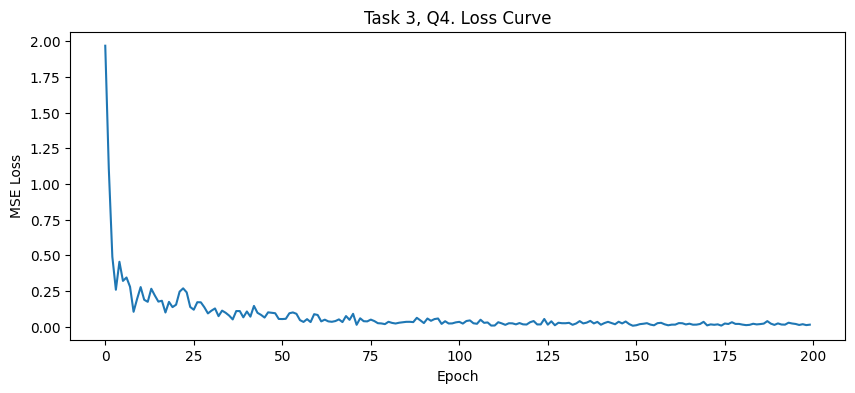

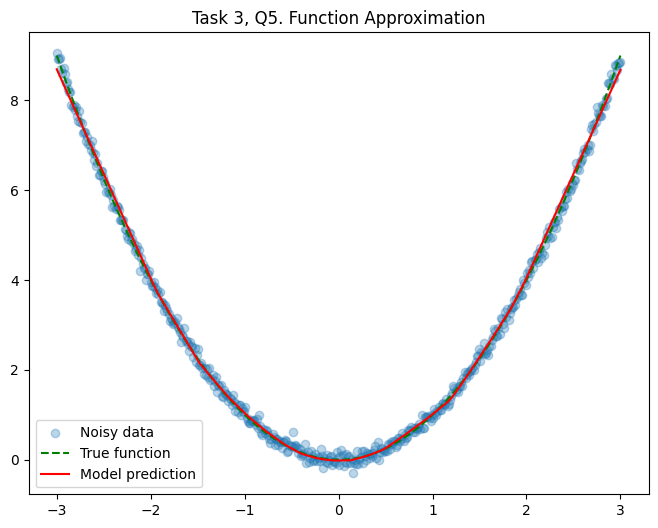

(TwoLayerMLP(
   (fc1): Linear(in_features=1, out_features=64, bias=True)
   (fc2): Linear(in_features=64, out_features=1, bias=True)
   (activation): ReLU()
 ),
 [1.9688748121261597,
  1.1084951162338257,
  0.4896205961704254,
  0.2582014799118042,
  0.45435166358947754,
  0.32027003169059753,
  0.34409281611442566,
  0.2790350914001465,
  0.10364192724227905,
  0.19437594711780548,
  0.2768522799015045,
  0.1879454255104065,
  0.1735043227672577,
  0.26514682173728943,
  0.21797099709510803,
  0.17511214315891266,
  0.18100781738758087,
  0.09874828904867172,
  0.17313829064369202,
  0.13645035028457642,
  0.15320102870464325,
  0.2447889894247055,
  0.2680293023586273,
  0.23992717266082764,
  0.1374458223581314,
  0.11815302819013596,
  0.1708432137966156,
  0.17010052502155304,
  0.13501803576946259,
  0.09227858483791351,
  0.11148660629987717,
  0.12710969150066376,
  0.0730820819735527,
  0.11182940006256104,
  0.09684060513973236,
  0.07703790813684464,
  0.05019117519259453,


In [ ]:
def task3():
    np.random.seed(42)
    x = np.linspace(-3, 3, 500).reshape(-1, 1)
    y = x**2 + np.random.normal(0, 0.1, x.shape)

    X_t = torch.FloatTensor(x).to(device)
    y_t = torch.FloatTensor(y).to(device)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Model
    model = TwoLayerMLP(input_size=1, hidden_size=64, output_size=1, activation="relu").to(device)
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    losses = []

    for _ in range(200):
        for xb, yb in loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            print(loss.item())
        losses.append(loss.item())

    # Q4: Loss curve
    plt.figure(figsize=(10,4))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Task 3, Q4. Loss Curve")
    plt.show()

    # Q5
    model.eval()
    with torch.no_grad():
        y_pred = model(X_t).cpu().numpy()

    plt.figure(figsize=(8,6))
    plt.scatter(x, y, label="Noisy data", alpha=0.3)
    plt.plot(x, x**2, "g--", label="True function")
    plt.plot(x, y_pred, "r", label="Model prediction")
    plt.legend()
    plt.title("Task 3, Q5. Function Approximation")
    plt.show()

    return model, losses, y_pred

# Run
task3()


### Task 3 Question 5 Observation:

Actual function is almost entirely mimicked by model prediction, with slight differences at the x-axis limits

## ---------------------------------------------------------------------